In [1]:
import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

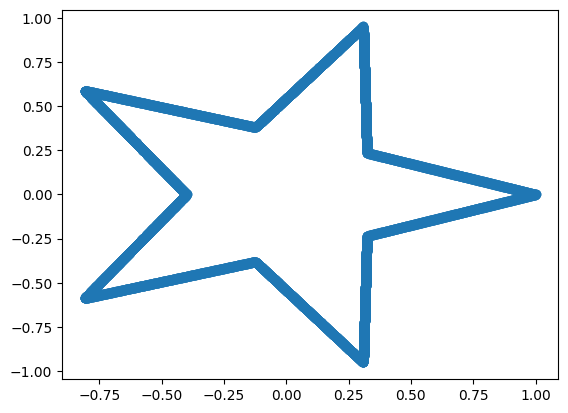

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [3]:
class Config:
    schedule_name = "linear"
    loss_weight_name = "uniform"

    beta_min = 0.1
    beta_max = 10.0
    cosine_s = 0.008

    lr = 1e-3
    epochs = 2000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000


SCHEDULES = {
    "linear": {"type": "linear", "beta_min": 0.1, "beta_max": 10.0},
    "cosine": {"type": "cosine", "cosine_s": 0.008},
}


LOSS_WEIGHTS = {
    "uniform": "w(t)=1",
    "snr": "w(t)=SNR(t)=alpha_bar/(1-alpha_bar)",
    "inv_snr": "w(t)=1/SNR(t)=(1-alpha_bar)/alpha_bar",
}


In [4]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [5]:
def clamp_t(t, config):
    return torch.clamp(t, 1e-6, 1.0 - 1e-6)

# линейные
def alpha_bar_linear(t, config):
    t = clamp_t(t, config)
    int_beta = config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t**2
    return torch.exp(-int_beta)


def beta_linear(t, config):
    t = clamp_t(t, config)
    return config.beta_min + t * (config.beta_max - config.beta_min)

# косинусовые
def alpha_bar_cosine(t, config):
    t = clamp_t(t, config)
    s = config.cosine_s

    angle = (t + s) / (1.0 + s) * (math.pi / 2.0)
    angle0 = s / (1.0 + s) * (math.pi / 2.0)

    f_t = torch.cos(angle) ** 2
    f_0 = math.cos(angle0) ** 2
    return f_t / f_0


def beta_cosine(t, config):
    t = clamp_t(t, config)
    s = config.cosine_s
    angle = (t + s) / (1.0 + s) * (math.pi / 2.0)
    return (math.pi / (1.0 + s)) * torch.tan(angle)

# общие
def alpha_bar_t(t, config):
    if schedule_type(config) == "linear":
        return alpha_bar_linear(t, config)
    elif schedule_type(config) == "cosine":
        return alpha_bar_cosine(t, config)
    else:
        raise ValueError(f"Unknown schedule: {config.schedule_name}")


def beta_t(t, config):
    if schedule_type(config) == "linear":
        return beta_linear(t, config)
    elif schedule_type(config) == "cosine":
        return beta_cosine(t, config)
    else:
        raise ValueError(f"Unknown schedule: {config.schedule_name}")


def alpha_t(t, config):
    return torch.sqrt(alpha_bar_t(t, config))


def sigma_t(t, config):
    ab = alpha_bar_t(t, config)
    return torch.sqrt(torch.clamp(1.0 - ab, min=1e-12))


def snr_t(t, config):
    ab = alpha_bar_t(t, config)
    snr = ab / torch.clamp(1.0 - ab, min=1e-12)
    return torch.clamp(snr, min=1e-4, max=1e4)


def loss_weight_t(t, config):
    name = config.loss_weight_name
    snr = snr_t(t, config)

    if name == "uniform":
        return torch.ones_like(t)
    if name == "snr":
        return snr
    if name == "inv_snr":
        return 1.0 / snr

    raise ValueError(f"Unknown loss weight: {name}")


def apply_schedule_from_name(config: Config):
    sch = SCHEDULES[config.schedule_name]
    if sch["type"] == "linear":
        config.beta_min = sch["beta_min"]
        config.beta_max = sch["beta_max"]
    elif sch["type"] == "cosine":
        config.cosine_s = sch["cosine_s"]
    else:
        raise ValueError(f"Unknown schedule type: {sch['type']}")
    return config


def schedule_type(config: Config):
    return SCHEDULES[config.schedule_name]["type"]


In [6]:
class VATrainer():
    def __init__(self, config):
        self.config = config
        apply_schedule_from_name(self.config)
        self.device = torch.device('cuda') if torch.cuda.is_available() else (torch.device('mps') if torch.mps.is_available() else 'cpu')

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0
        total_n = 0

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device)
            alpha = alpha_t(t, self.config)
            sigma = sigma_t(t, self.config)

            z = torch.randn_like(batch)
            x_t = alpha * batch + sigma * z

            pred_z = self.model(x_t, t)
            per_sample_mse = ((pred_z - z) ** 2).mean(dim=1, keepdim=True)
            weights = loss_weight_t(t, self.config)
            loss = (weights * per_sample_mse).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            bs = batch.shape[0]
            total_loss += loss.item() * bs
            total_n += bs

        return total_loss / total_n


    def run(self):
        history = []
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            history.append(loss)
            if n % 100 == 0:
                print(f'Loss: {loss}')
        return history


In [7]:
config = Config()
trainer = VATrainer(config)

In [8]:
def sample(model, config, num_samples=1000, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 1e-6)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            beta = beta_t(t_tensor, config)
            sigma = sigma_t(t_tensor, config)

            pred = model(x, t_tensor)
            score = -pred / (sigma + 1e-12)

            f = -0.5 * beta * x
            g = torch.sqrt(beta)
            reverse_drift = f - (g ** 2) * score

            noise = torch.randn_like(x) if i < config.num_timesteps - 1 else torch.zeros_like(x)
            x = x - reverse_drift * dt + g * math.sqrt(dt) * noise

        return x.cpu().numpy()


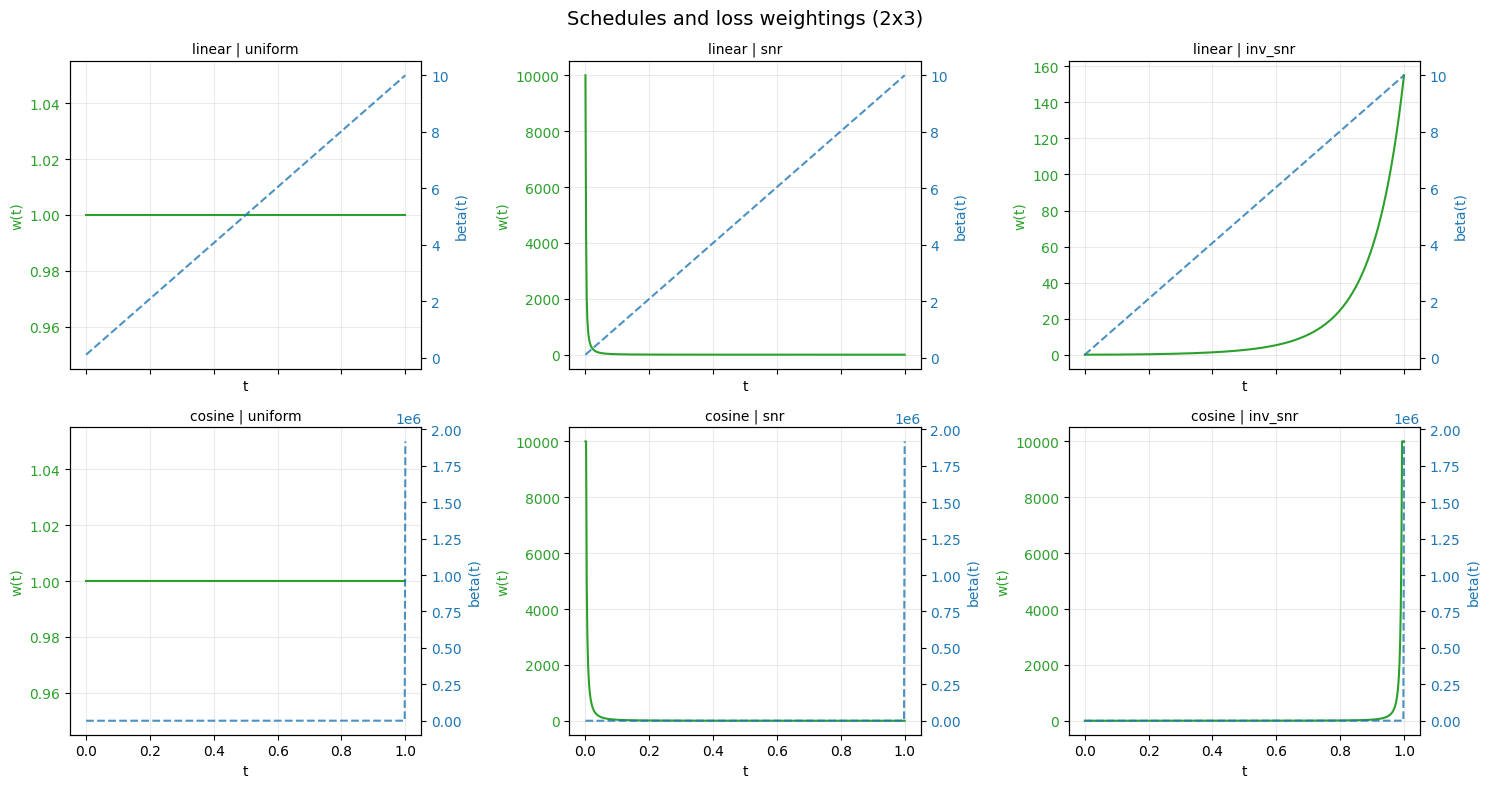

Schedules: ['linear', 'cosine']
Loss weightings: ['uniform', 'snr', 'inv_snr']


In [9]:
# === Init: 2 schedules x 3 loss-weight variants ===
schedule_names = list(SCHEDULES.keys())
loss_weight_names = list(LOSS_WEIGHTS.keys())
experiment_grid = [(sch, lw) for sch in schedule_names for lw in loss_weight_names]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
t = torch.linspace(1e-4, 1.0, 500).unsqueeze(1)

for ax, (schedule_name, loss_weight_name) in zip(axes.flat, experiment_grid):
    cfg = Config()
    cfg.schedule_name = schedule_name
    cfg.loss_weight_name = loss_weight_name
    apply_schedule_from_name(cfg)

    w_vals = loss_weight_t(t, cfg).detach().cpu().numpy().squeeze()
    beta_vals = beta_t(t, cfg).detach().cpu().numpy().squeeze()

    ax.plot(t.squeeze().cpu().numpy(), w_vals, color='tab:green', label='normalized w(t)')
    ax.set_title(f'{schedule_name} | {loss_weight_name}', fontsize=10)
    ax.set_xlabel('t')
    ax.set_ylabel('w(t)', color='tab:green')
    ax.tick_params(axis='y', labelcolor='tab:green')
    ax.grid(alpha=0.25)

    ax2 = ax.twinx()
    ax2.plot(t.squeeze().cpu().numpy(), beta_vals, '--', color='tab:blue', alpha=0.8, label='beta(t)')
    ax2.set_ylabel('beta(t)', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

fig.suptitle('Schedules and loss weightings (2x3)', fontsize=14)
plt.tight_layout()
plt.show()

print('Schedules:', schedule_names)
print('Loss weightings:', loss_weight_names)



Training: schedule=linear, weight=uniform
Loss: 0.9038137865066528
Loss: 0.24656706686019897
Loss: 0.2401574035167694
Loss: 0.23089941530227662
Loss: 0.23370170278549193
Loss: 0.2207669716358185
Loss: 0.21667103822231293
Loss: 0.22701826326847077
Loss: 0.22001183485984802
Loss: 0.21713179135322572
Loss: 0.22227728834152222
Loss: 0.2193358069419861
Loss: 0.21603111815452575
Loss: 0.22752111926078797
Loss: 0.21530170407295227
Loss: 0.21094616832733154
Loss: 0.21801475749015808
Loss: 0.2167319914340973
Loss: 0.21043842403888702
Loss: 0.21252626729011537

Training: schedule=linear, weight=snr
Loss: 43.875824047851566
Loss: 43.269983404541016
Loss: 44.218857208251954
Loss: 31.455780041503907
Loss: 38.91700707397461
Loss: 47.23857224731445
Loss: 29.72363394165039
Loss: 37.42788101806641
Loss: 38.13710543365479
Loss: 31.100577072143555
Loss: 46.241730235290525
Loss: 49.38304040832519
Loss: 25.293509913635255
Loss: 25.630548919677736
Loss: 33.444922747802735
Loss: 26.402663369750975
Loss: 34.

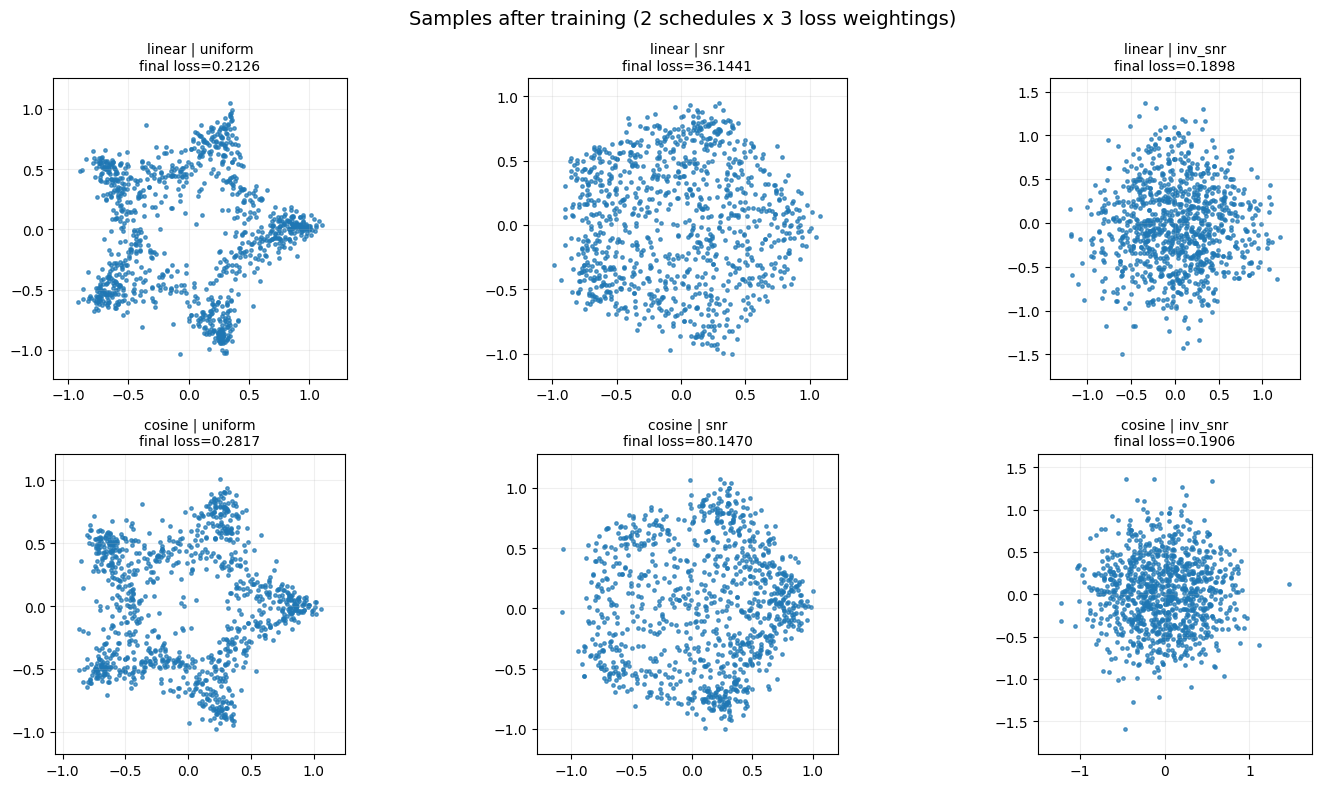

In [10]:
# === Train + sample: all 6 combinations ===
results = {}
all_samples = {}

for schedule_name in schedule_names:
    for loss_weight_name in loss_weight_names:
        cfg = Config()
        cfg.schedule_name = schedule_name
        cfg.loss_weight_name = loss_weight_name

        print(f"\nTraining: schedule={schedule_name}, weight={loss_weight_name}")
        tr = VATrainer(cfg)
        history = tr.run()

        key = (schedule_name, loss_weight_name)
        results[key] = {
            'trainer': tr,
            'history': history,
            'final_loss': history[-1],
        }
        all_samples[key] = sample(tr.model, tr.config, num_samples=1000, device=tr.device)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (schedule_name, loss_weight_name) in zip(axes.flat, experiment_grid):
    key = (schedule_name, loss_weight_name)
    s = all_samples[key]
    final_loss = results[key]['final_loss']

    x_min, y_min = s.min(axis=0)
    x_max, y_max = s.max(axis=0)
    pad_x = 0.1 * max(x_max - x_min, 1e-6)
    pad_y = 0.1 * max(y_max - y_min, 1e-6)

    ax.scatter(s[:, 0], s[:, 1], s=6, alpha=0.7)
    ax.set_title(f'{schedule_name} | {loss_weight_name}\nfinal loss={final_loss:.4f}', fontsize=10)
    ax.set_xlim(x_min - pad_x, x_max + pad_x)
    ax.set_ylim(y_min - pad_y, y_max + pad_y)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.2)

fig.suptitle('Samples after training (2 schedules x 3 loss weightings)', fontsize=14)
plt.tight_layout()
plt.show()


# Вывод
равномерное взвешивание лучше всего показало себя
в snr данные приобретают форму пятиугольника, inv_snr совсем плохо справляется при наших условиях, данные остаются шумом. 

расписания не сильно повлияли но на глаз линейное показало себя менее шумным